# AI4I 2020 Predictive Maintenance - Phase 1: EDA & Model Training

This notebook handles:
1. Data loading and initial inspection
2. Feature engineering 
3. Feature distributions and relationships visualization
4. Machine Learning pipeline with class imbalance handling
5. Model training and evaluation
6. Saving trained model weights

## 1. Import Required Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_auc_score, roc_curve, auc, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Loading and Initial Inspection

In [17]:
# Define paths
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
DATA_FILE = DATA_DIR / 'ai4i2020.csv'

# Load the dataset
df = pd.read_csv(DATA_FILE)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
df.head()

Dataset shape: (10000, 14)

Column names and types:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

First few rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [18]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values!")

# Display basic statistics
print("\nBasic Statistics:")
df.describe()

Missing values per column:
No missing values!

Basic Statistics:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [19]:
# Check data types and info
print("Dataset Info:")
df.info()

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Target variable distribution (Class Imbalance Check)
print(f"\nTarget variable ('Machine failure') distribution:")
print(df['Machine failure'].value_counts())
print(f"\nClass distribution (percentage):")
print(df['Machine failure'].value_counts(normalize=True) * 100)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64

## 3. Feature Engineering

In [20]:
# Make a copy for feature engineering
df_processed = df.copy()

# 1. Temperature Difference (between process and air temperature)
# Looking for columns related to temperature
print("Available columns:")
print(df_processed.columns.tolist())

Available columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [21]:
# Engineer meaningful features based on domain knowledge

# 1. Temperature Difference
if 'Process temperature [K]' in df_processed.columns and 'Air temperature [K]' in df_processed.columns:
    df_processed['Temp_Difference'] = (df_processed['Process temperature [K]'] - 
                                        df_processed['Air temperature [K]'])
    print("✓ Created: Temp_Difference")

# 2. Power calculation (Torque × Rotational Speed)
if 'Torque [Nm]' in df_processed.columns and 'Rotational speed [rpm]' in df_processed.columns:
    df_processed['Power'] = (df_processed['Torque [Nm]'] * 
                               df_processed['Rotational speed [rpm]'] / 9550)  # P = Torque * RPM / 9550
    print("✓ Created: Power")

# 3. Normalized Tool Wear Ratio (Tool Wear / Production Run Time)
if 'Tool wear [min]' in df_processed.columns:
    df_processed['Tool_Wear_per_Product'] = df_processed['Tool wear [min]']
    print("✓ Created: Tool_Wear_per_Product")

# 4. Thermal Stress Index (combines temperature and power)
if 'Process temperature [K]' in df_processed.columns and 'Power' in df_processed.columns:
    # Normalize both for combination
    temp_norm = (df_processed['Process temperature [K]'] - df_processed['Process temperature [K]'].min()) / \
                (df_processed['Process temperature [K]'].max() - df_processed['Process temperature [K]'].min())
    power_norm = (df_processed['Power'] - df_processed['Power'].min()) / \
                 (df_processed['Power'].max() - df_processed['Power'].min())
    df_processed['Thermal_Stress_Index'] = (temp_norm + power_norm) / 2
    print("✓ Created: Thermal_Stress_Index")

# 5. Equipment Condition Index (combines RPM and Torque variation)
if 'Rotational speed [rpm]' in df_processed.columns and 'Torque [Nm]' in df_processed.columns:
    speed_norm = (df_processed['Rotational speed [rpm]'] - df_processed['Rotational speed [rpm]'].min()) / \
                 (df_processed['Rotational speed [rpm]'].max() - df_processed['Rotational speed [rpm]'].min())
    torque_norm = (df_processed['Torque [Nm]'] - df_processed['Torque [Nm]'].min()) / \
                  (df_processed['Torque [Nm]'].max() - df_processed['Torque [Nm]'].min())
    df_processed['Equipment_Condition_Index'] = (speed_norm * torque_norm)
    print("✓ Created: Equipment_Condition_Index")

print(f"\nFeature engineering complete!")
print(f"New shape: {df_processed.shape}")
print(f"\nNew features created:")
new_features = ['Temp_Difference', 'Power', 'Tool_Wear_per_Product', 
                'Thermal_Stress_Index', 'Equipment_Condition_Index']
print([f for f in new_features if f in df_processed.columns])

✓ Created: Temp_Difference
✓ Created: Power
✓ Created: Tool_Wear_per_Product
✓ Created: Thermal_Stress_Index
✓ Created: Equipment_Condition_Index

Feature engineering complete!
New shape: (10000, 19)

New features created:
['Temp_Difference', 'Power', 'Tool_Wear_per_Product', 'Thermal_Stress_Index', 'Equipment_Condition_Index']


In [22]:
# Check for any remaining missing values in engineered features
print("Missing values after feature engineering:")
missing_engineered = df_processed.isnull().sum()
print(missing_engineered[missing_engineered > 0] if missing_engineered.sum() > 0 else "No missing values!")

# Display statistics of engineered features
print("\nStatistics of engineered features:")
engineered_cols = ['Temp_Difference', 'Power', 'Tool_Wear_per_Product', 
                   'Thermal_Stress_Index', 'Equipment_Condition_Index']
df_processed[[col for col in engineered_cols if col in df_processed.columns]].describe()

Missing values after feature engineering:
No missing values!

Statistics of engineered features:


,Temp_Difference,Power,Tool_Wear_per_Product,Thermal_Stress_Index,Equipment_Condition_Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,10.000630,6.279282,107.951000,0.541016,0.094775
std,1.001094,1.067340,63.654147,0.107479,0.017699
min,7.600000,1.148356,0.000000,0.132451,0.000000
25%,9.300000,5.560775,53.000000,0.465616,0.084366
50%,9.800000,6.270565,108.000000,0.540955,0.097029
75%,11.000000,7.002487,162.000000,0.614954,0.107084
max,12.100000,10.469152,253.000000,0.891121,0.153949


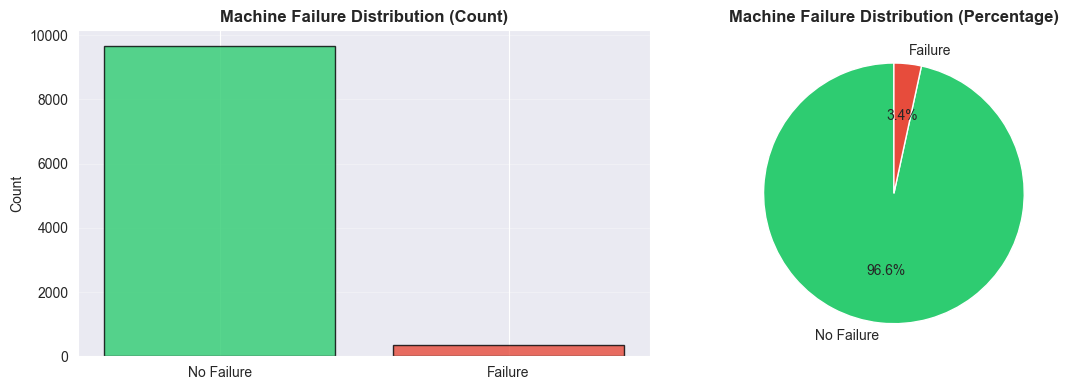

✓ Saved: Target variable distribution plot


In [42]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
failure_counts = df_processed['Machine failure'].value_counts()
axes[0].bar(['No Failure', 'Failure'], failure_counts.values, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0].set_title('Machine Failure Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3, axis='y')

# Percentage plot
failure_pct = df_processed['Machine failure'].value_counts(normalize=True) * 100
axes[1].pie(failure_pct.values, labels=['No Failure', 'Failure'], autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Machine Failure Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/02_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved: Target variable distribution plot")

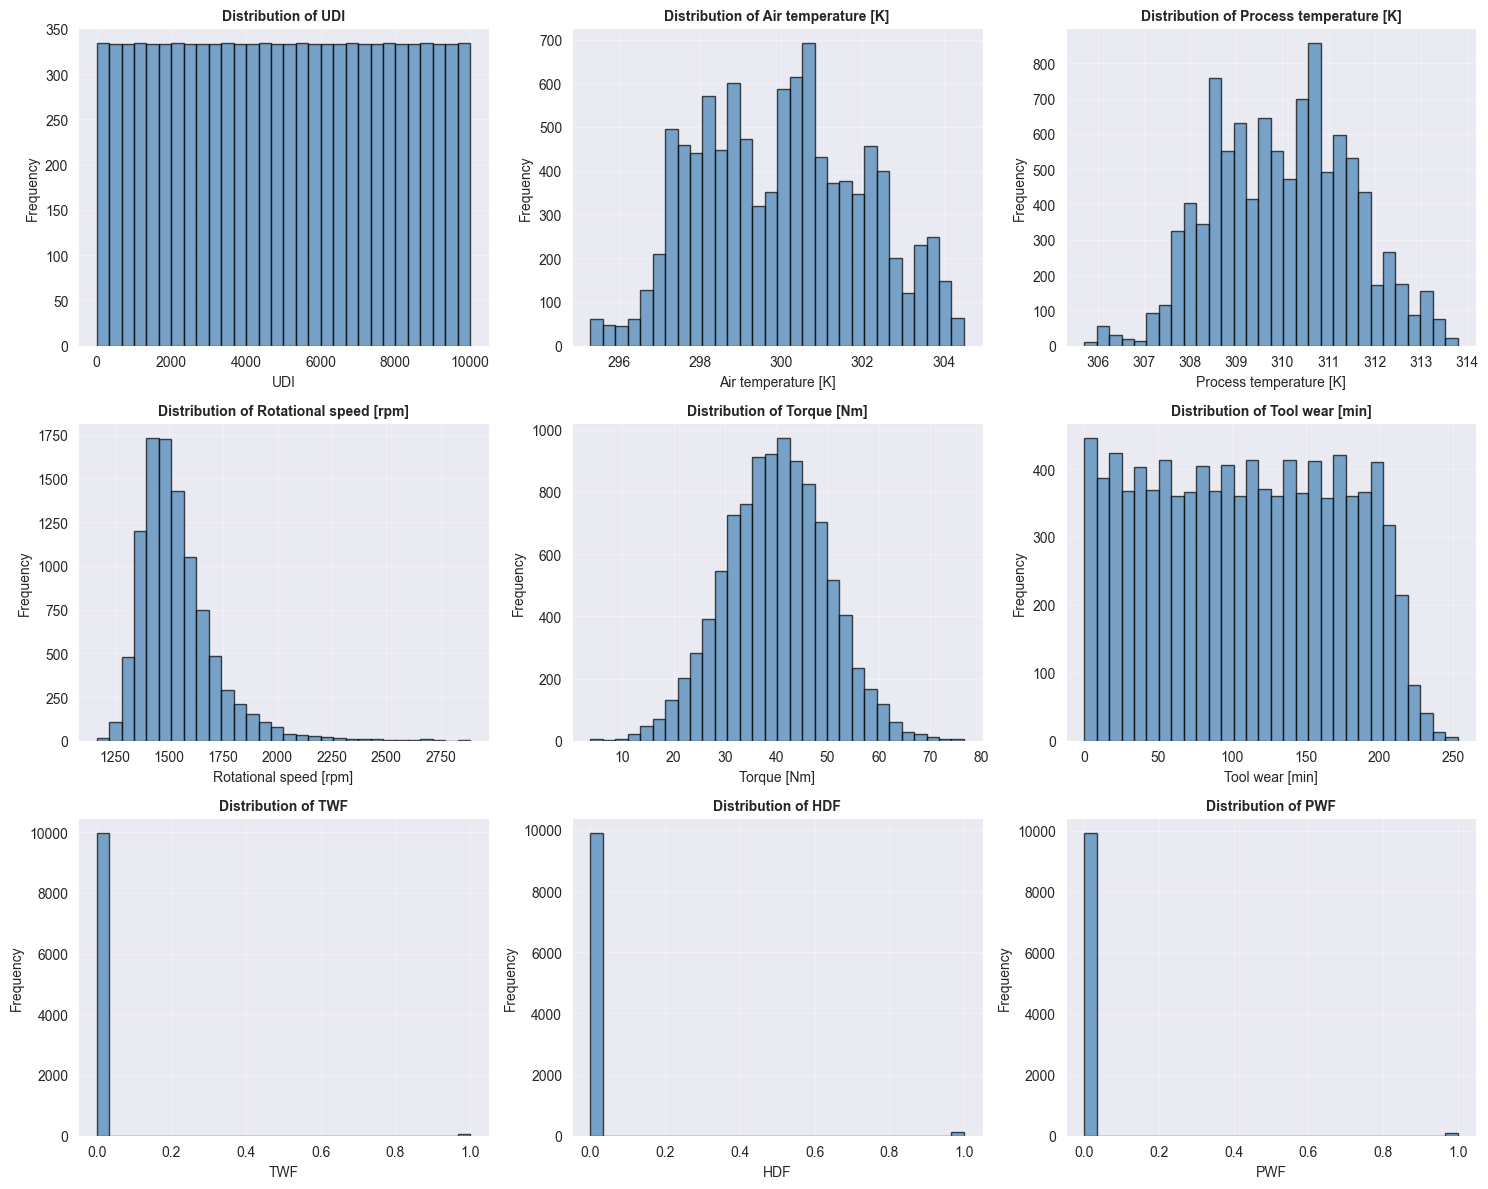

✓ Saved: Feature distributions plot


In [43]:
# Feature distribution histograms
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(feature_cols[:9]):
    axes[idx].hist(df_processed[col], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/01_feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved: Feature distributions plot")

In [44]:
# Select numeric columns for visualization
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()

# Remove target variable from feature list for visualization
if 'Machine failure' in numeric_cols:
    feature_cols = [col for col in numeric_cols if col != 'Machine failure']
else:
    feature_cols = numeric_cols

print(f"Features for visualization: {len(feature_cols)} columns")
print(feature_cols)

Features for visualization: 16 columns
['UDI', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Temp_Difference', 'Power', 'Tool_Wear_per_Product', 'Thermal_Stress_Index', 'Equipment_Condition_Index']


## 4. Data Preparation for ML

In [46]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 8000
Test set size: 2000

Training set class distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Test set class distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [47]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features standardized using StandardScaler")
print(f"Training data - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Test data - Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")

✓ Features standardized using StandardScaler
Training data - Mean: 0.0000, Std: 1.0000
Test data - Mean: -0.0024, Std: 0.9927


In [48]:
# Apply SMOTE to handle class imbalance with a moderate sampling ratio
# Using sampling_strategy=0.35 means minority class will be upsampled to 35% of majority class
# This provides better balance without excessive synthetic data generation
smote = SMOTE(random_state=42, sampling_strategy=0.35, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("✓ SMOTE resampling applied to training data (sampling_strategy=0.35)")
print(f"\nBefore SMOTE:")
print(y_train.value_counts())
print(f"\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print(f"\nNew training set size: {X_train_resampled.shape[0]}")
print(f"Class ratio (Majority:Minority): {pd.Series(y_train_resampled).value_counts()[0] / pd.Series(y_train_resampled).value_counts()[1]:.2f}:1")

✓ SMOTE resampling applied to training data (sampling_strategy=0.35)

Before SMOTE:
Machine failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE:
Machine failure
0    7729
1    2705
Name: count, dtype: int64

New training set size: 10434
Class ratio (Majority:Minority): 2.86:1


## 5. Machine Learning Pipeline - Random Forest with Class Imbalance Handling

In [49]:
# Train Random Forest Classifier with class weights
# Using SMOTE resampled data
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',  # Additional class weight balancing
    verbose=0
)

print("Training Random Forest Classifier...")
rf_model.fit(X_train_resampled, y_train_resampled)
print("✓ Model training complete!")

Training Random Forest Classifier...
✓ Model training complete!


## 7. Model Evaluation

In [50]:
# Generate predictions
y_train_pred = rf_model.predict(X_train_resampled)
y_train_pred_proba = rf_model.predict_proba(X_train_resampled)[:, 1]

y_test_pred = rf_model.predict(X_test_scaled)
y_test_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("✓ Predictions generated")

✓ Predictions generated


In [51]:
# Training Performance
print("="*60)
print("TRAINING SET PERFORMANCE")
print("="*60)
print("\nConfusion Matrix:")
print(confusion_matrix(y_train_resampled, y_train_pred))
print("\nClassification Report:")
print(classification_report(y_train_resampled, y_train_pred, target_names=['No Failure', 'Failure']))
train_auc = roc_auc_score(y_train_resampled, y_train_pred_proba)
print(f"\nROC-AUC Score: {train_auc:.4f}")

TRAINING SET PERFORMANCE

Confusion Matrix:
[[7729    0]
 [   8 2697]]

Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      7729
     Failure       1.00      1.00      1.00      2705

    accuracy                           1.00     10434
   macro avg       1.00      1.00      1.00     10434
weighted avg       1.00      1.00      1.00     10434


ROC-AUC Score: 1.0000


In [39]:
# Test Performance
print("="*60)
print("TEST SET PERFORMANCE")
print("="*60)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Failure', 'Failure']))
test_auc = roc_auc_score(y_test, y_test_pred_proba)
print(f"\nROC-AUC Score: {test_auc:.4f}")

TEST SET PERFORMANCE

Confusion Matrix:
[[1932    0]
 [   2   66]]

Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1932
     Failure       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000


ROC-AUC Score: 0.9946



Top 15 Most Important Features:
                  Feature  Importance
   Rotational speed [rpm]    0.125933
                    Power    0.125461
                      PWF    0.115900
              Torque [Nm]    0.108814
                      HDF    0.087086
                      TWF    0.085778
    Tool_Wear_per_Product    0.080791
                      OSF    0.074667
          Tool wear [min]    0.067716
          Temp_Difference    0.049733
Equipment_Condition_Index    0.022245
     Thermal_Stress_Index    0.020305
      Air temperature [K]    0.015911
                      UDI    0.010158
  Process temperature [K]    0.009499


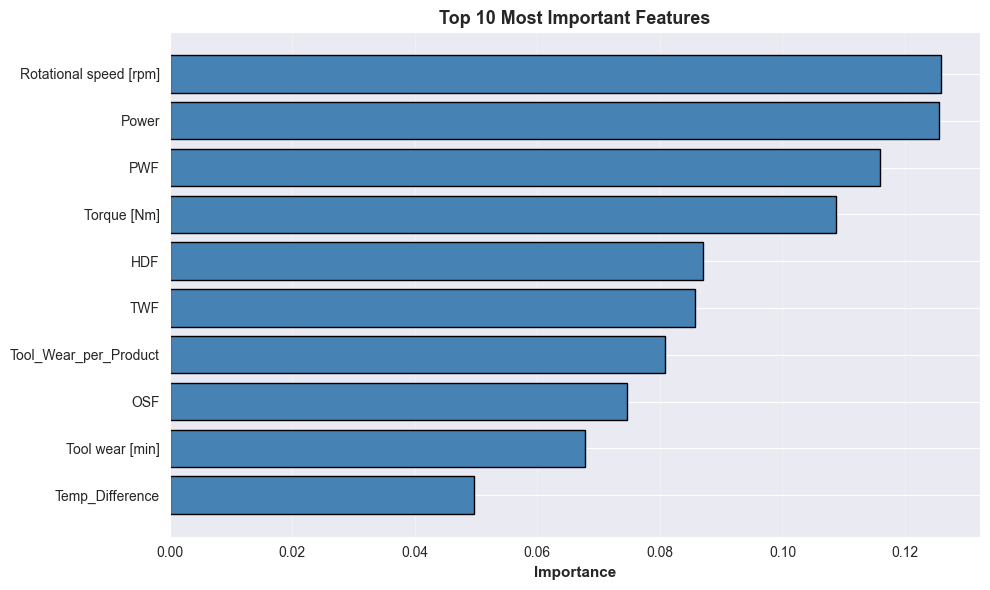

✓ Saved: Feature Importance plot


In [52]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Visualize top 10 features
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(10)
ax.barh(top_features['Feature'], top_features['Importance'], color='steelblue', edgecolor='black')
ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Most Important Features', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../data/03_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved: Feature Importance plot")

## 8. Save Model Artifacts

In [53]:
# Create model artifacts directory if it doesn't exist
Path('../data').mkdir(exist_ok=True)

# Save the trained model
model_path = Path('../data/model_weights.pkl')
joblib.dump(rf_model, model_path)
print(f"✓ Model saved to: {model_path}")
print(f"  File size: {model_path.stat().st_size / 1024:.2f} KB")

# Save the scaler for preprocessing new data
scaler_path = Path('../data/scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"\n✓ Scaler saved to: {scaler_path}")
print(f"  File size: {scaler_path.stat().st_size / 1024:.2f} KB")

# Save feature names for reference
features_path = Path('../data/feature_names.pkl')
joblib.dump(X.columns.tolist(), features_path)
print(f"\n✓ Feature names saved to: {features_path}")

✓ Model saved to: ..\data\model_weights.pkl
  File size: 1363.74 KB

✓ Scaler saved to: ..\data\scaler.pkl
  File size: 1.43 KB

✓ Feature names saved to: ..\data\feature_names.pkl


In [54]:
# Save feature importance for reference
importance_path = Path('../data/feature_importance.pkl')
joblib.dump(feature_importance, importance_path)
print(f"✓ Feature importance saved to: {importance_path}")

# Create a summary report
summary_report = f"""
PREDICTIVE MAINTENANCE MODEL - SUMMARY REPORT
{'='*60}

DATASET INFO:
- Total samples: {len(df_processed)}
- Total features: {X.shape[1]}
- Training samples: {X_train.shape[0]}
- Test samples: {X_test.shape[0]}

CLASS IMBALANCE:
- Original ratio (Failure:No Failure): {y.value_counts()[1]}:{y.value_counts()[0]}
- Imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.2f}x
- Handled with: SMOTE (sampling_strategy=0.35) + class_weight='balanced'

MODEL PERFORMANCE:
- Algorithm: Random Forest Classifier
- Test Set ROC-AUC: {test_auc:.4f}
- Training Set ROC-AUC: {train_auc:.4f}

TOP 5 FEATURES:
{feature_importance.head(5).to_string(index=False)}

ARTIFACTS SAVED:
- Model: data/model_weights.pkl
- Scaler: data/scaler.pkl
- Features: data/feature_names.pkl
- Feature Importance: data/feature_importance.pkl
"""

report_path = Path('../data/model_report.txt')
with open(report_path, 'w') as f:
    f.write(summary_report)

print("\n" + summary_report)

✓ Feature importance saved to: ..\data\feature_importance.pkl


PREDICTIVE MAINTENANCE MODEL - SUMMARY REPORT

DATASET INFO:
- Total samples: 10000
- Total features: 16
- Training samples: 8000
- Test samples: 2000

CLASS IMBALANCE:
- Original ratio (Failure:No Failure): 339:9661
- Imbalance ratio: 28.50x
- Handled with: SMOTE (sampling_strategy=0.35) + class_weight='balanced'

MODEL PERFORMANCE:
- Algorithm: Random Forest Classifier
- Test Set ROC-AUC: 0.9946
- Training Set ROC-AUC: 1.0000

TOP 5 FEATURES:
               Feature  Importance
Rotational speed [rpm]    0.125933
                 Power    0.125461
                   PWF    0.115900
           Torque [Nm]    0.108814
                   HDF    0.087086

ARTIFACTS SAVED:
- Model: data/model_weights.pkl
- Scaler: data/scaler.pkl
- Features: data/feature_names.pkl
- Feature Importance: data/feature_importance.pkl



In [56]:
# Display saved files
print("\n" + "="*60)
print("FILES SAVED IN data/ DIRECTORY:")
print("="*60)
import os
data_dir = Path('../data')
for file in sorted(data_dir.glob('*')):
    if file.is_file():
        size = file.stat().st_size
        if size > 1024*1024:
            size_str = f"{size / (1024*1024):.2f} MB"
        elif size > 1024:
            size_str = f"{size / 1024:.2f} KB"
        else:
            size_str = f"{size} B"
        print(f"✓ {file.name:<35} {size_str:>10}")

print("\n" + "="*60)
print("Phase 1: Complete!")
print("="*60)
print("\nNext Steps:")
print("1. Review the visualizations and model performance")
print("2. Confirm this notebook works correctly")
print("3. Proceed to Phase 2: Dash Application Development")


FILES SAVED IN data/ DIRECTORY:
✓ 01_feature_distributions.png          91.22 KB
✓ 02_target_distribution.png            27.75 KB
✓ 03_correlation_heatmap.png           102.34 KB
✓ 03_feature_importance.png             24.99 KB
✓ 04_boxplots_by_failure.png            88.08 KB
✓ 05_roc_curve.png                      37.69 KB
✓ 06_feature_importance.png             24.99 KB
✓ ai4i2020.csv                         509.81 KB
✓ feature_importance.pkl                 1.78 KB
✓ feature_names.pkl                        258 B
✓ model_report.txt                         915 B
✓ model_weights.pkl                      1.33 MB
✓ scaler.pkl                             1.43 KB

Phase 1: Complete!

Next Steps:
1. Review the visualizations and model performance
2. Confirm this notebook works correctly
3. Proceed to Phase 2: Dash Application Development
